# Exploracion y Analisis del Dataset de Jeopardy: 216,000+ Preguntas

Este proyecto analiza un extenso dataset de mas de 216,000 preguntas del programa de television **Jeopardy!**, uno de los concursos de conocimiento mas iconicos de la television estadounidense. El analisis incluye limpieza de datos, funciones de busqueda reutilizables, analisis de valor/dificultad y exploracion de patrones temporales y tematicos.

**Aspectos clave:**
- Manejo de un dataset a gran escala (+216K registros)
- Limpieza de datos con formatos inconsistentes
- Funciones reutilizables para filtrado y agregacion
- Analisis de dificultad por tema y epoca
- Visualizaciones de tendencias y distribuciones

**Dataset:** Archivo CSV con preguntas de Jeopardy!, incluyendo fecha de emision, categoria, valor, pregunta y respuesta.

## 1. Carga y Limpieza de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

# Cargar datos
df = pd.read_csv('jeopardy.csv')

# Limpiar nombres de columnas (tienen espacios extra)
df.columns = ['Show Number', 'Air Date', 'Round', 'Category', 'Value', 'Question', 'Answer']

# Convertir Air Date a datetime
df['Air Date'] = pd.to_datetime(df['Air Date'])
df['Year'] = df['Air Date'].dt.year

# Convertir Value a numerico
df['Value_Numeric'] = df['Value'].apply(
    lambda x: float(x[1:].replace(',', '')) if isinstance(x, str) and x != 'no value' and x.startswith('$') else 0
)

print(f"Dataset: {df.shape[0]:,} preguntas, {df.shape[1]} variables")
print(f"Periodo: {df['Air Date'].min().strftime('%Y-%m-%d')} a {df['Air Date'].max().strftime('%Y-%m-%d')}")
print(f"Categorias unicas: {df['Category'].nunique():,}")
print(f"Shows unicos: {df['Show Number'].nunique():,}")
print()
df.head()

Dataset: 216,930 preguntas, 9 variables
Periodo: 1984-09-10 a 2012-01-27
Categorias unicas: 27,995
Shows unicos: 3,640



,Show Number,Air Date,Round,Category,Value,Question,Answer,Year,Value_Numeric
0,4680,2004-12-31,Jeopardy!,HISTORY,$200,"For the last 8 years of his life, Galileo was ...",Copernicus,2004,200.0
1,4680,2004-12-31,Jeopardy!,ESPN's TOP 10 ALL-TIME ATHLETES,$200,No. 2: 1912 Olympian; football star at Carlisl...,Jim Thorpe,2004,200.0
2,4680,2004-12-31,Jeopardy!,EVERYBODY TALKS ABOUT IT...,$200,The city of Yuma in this state has a record av...,Arizona,2004,200.0
3,4680,2004-12-31,Jeopardy!,THE COMPANY LINE,$200,"In 1963, live on ""The Art Linkletter Show"", th...",McDonald's,2004,200.0
4,4680,2004-12-31,Jeopardy!,EPITAPHS & TRIBUTES,$200,"Signer of the Dec. of Indep., framer of the Co...",John Adams,2004,200.0


In [2]:
# Resumen de la estructura
print("=" * 55)
print("ESTRUCTURA DEL DATASET")
print("=" * 55)
print(f"\nTipos de datos:")
print(df.dtypes.to_string())
print(f"\nValores nulos:")
print(df.isnull().sum().to_string())
print(f"\nRondas disponibles:")
for round_name, count in df['Round'].value_counts().items():
    print(f"  {round_name}: {count:,} ({count/len(df)*100:.1f}%)")

ESTRUCTURA DEL DATASET

Tipos de datos:
Show Number               int64
Air Date         datetime64[ns]
Round                    object
Category                 object
Value                    object
Question                 object
Answer                   object
Year                      int32
Value_Numeric           float64

Valores nulos:


Show Number      0
Air Date         0
Round            0
Category         0
Value            0
Question         0
Answer           2
Year             0
Value_Numeric    0

Rondas disponibles:
  Jeopardy!: 107,384 (49.5%)
  Double Jeopardy!: 105,912 (48.8%)
  Final Jeopardy!: 3,631 (1.7%)
  Tiebreaker: 3 (0.0%)


## 2. Funciones de Filtrado y Busqueda

Se desarrollan funciones reutilizables para explorar el dataset de manera flexible. Estas funciones permiten filtrar preguntas por palabras clave y analizar respuestas frecuentes.

In [3]:
def filter_questions(data, words):
    """Filtra preguntas que contengan TODAS las palabras especificadas (case-insensitive)."""
    filter_fn = lambda x: all(word.lower() in str(x).lower() for word in words)
    return data.loc[data['Question'].apply(filter_fn)]

def top_answers(data, n=10):
    """Retorna las N respuestas mas frecuentes en un subset de datos."""
    return data['Answer'].value_counts().head(n)

def avg_difficulty(data):
    """Calcula el valor promedio de las preguntas (proxy de dificultad)."""
    return data['Value_Numeric'].mean()

# Ejemplo: preguntas sobre "King" y "England"
kings = filter_questions(df, ['King', 'England'])
print(f"Preguntas sobre 'King' + 'England': {len(kings):,}")
print(f"Valor promedio: ${avg_difficulty(kings):,.0f}")
print(f"\nTop 5 respuestas:")
for answer, count in top_answers(kings, 5).items():
    print(f"  {answer}: {count}")

Preguntas sobre 'King' + 'England': 152
Valor promedio: $887

Top 5 respuestas:
  William the Conqueror: 6
  Edward: 3
  Richard the Lionhearted: 3
  Oliver Cromwell: 3
  Henry VIII: 3


In [4]:
# Mas ejemplos de busqueda
topics = {
    'Science': ['science', 'scientist'],
    'History': ['history', 'war'],
    'Literature': ['book', 'author'],
    'Geography': ['country', 'capital'],
    'Music': ['music', 'song']
}

print("=" * 60)
print("ANALISIS POR TEMA")
print("=" * 60)
for topic, words in topics.items():
    filtered = filter_questions(df, words)
    print(f"\n  {topic} ({words}):")
    print(f"    Preguntas: {len(filtered):,}")
    print(f"    Valor promedio: ${avg_difficulty(filtered):,.0f}")
    print(f"    Respuesta mas comun: {filtered['Answer'].mode().iloc[0] if len(filtered) > 0 else 'N/A'}")

ANALISIS POR TEMA



  Science (['science', 'scientist']):
    Preguntas: 1
    Valor promedio: $600
    Respuesta mas comun: forensic scientist



  History (['history', 'war']):
    Preguntas: 45
    Valor promedio: $596
    Respuesta mas comun: Cy Young



  Literature (['book', 'author']):
    Preguntas: 178
    Valor promedio: $792
    Respuesta mas comun: Dr. Seuss



  Geography (['country', 'capital']):
    Preguntas: 182
    Valor promedio: $817
    Respuesta mas comun: Nigeria



  Music (['music', 'song']):
    Preguntas: 163
    Valor promedio: $766
    Respuesta mas comun: 1776


## 3. Analisis de Valor y Dificultad

Exploramos como se distribuyen los valores de las preguntas y si existen patrones en la dificultad.

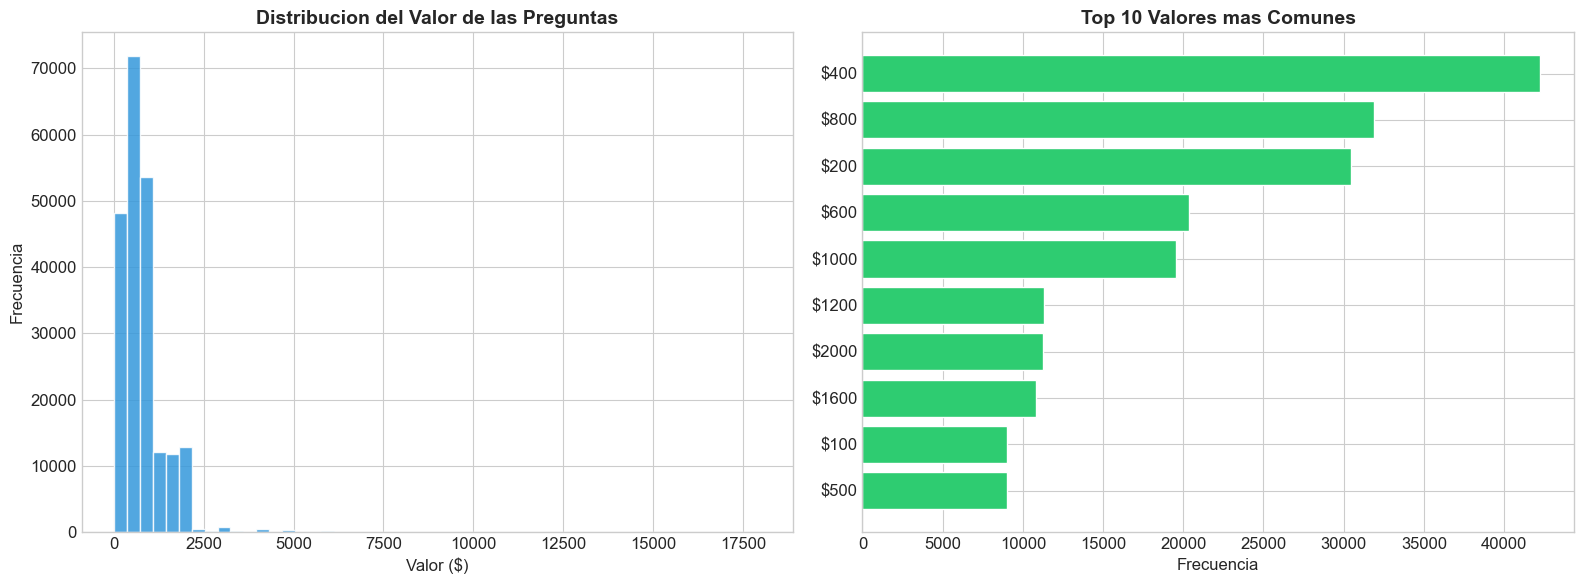

Valor promedio: $753
Valor mediano: $600
Valor maximo: $18,000


In [5]:
# Distribucion de valores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de valores (excluyendo 0)
values_nonzero = df[df['Value_Numeric'] > 0]['Value_Numeric']
axes[0].hist(values_nonzero, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribucion del Valor de las Preguntas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Valor ($)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# Top valores mas comunes
top_values = df['Value'].value_counts().head(10)
bars = axes[1].barh(top_values.index.astype(str), top_values.values, color='#2ecc71', edgecolor='white')
axes[1].set_title('Top 10 Valores mas Comunes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frecuencia', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Valor promedio: ${values_nonzero.mean():,.0f}")
print(f"Valor mediano: ${values_nonzero.median():,.0f}")
print(f"Valor maximo: ${values_nonzero.max():,.0f}")

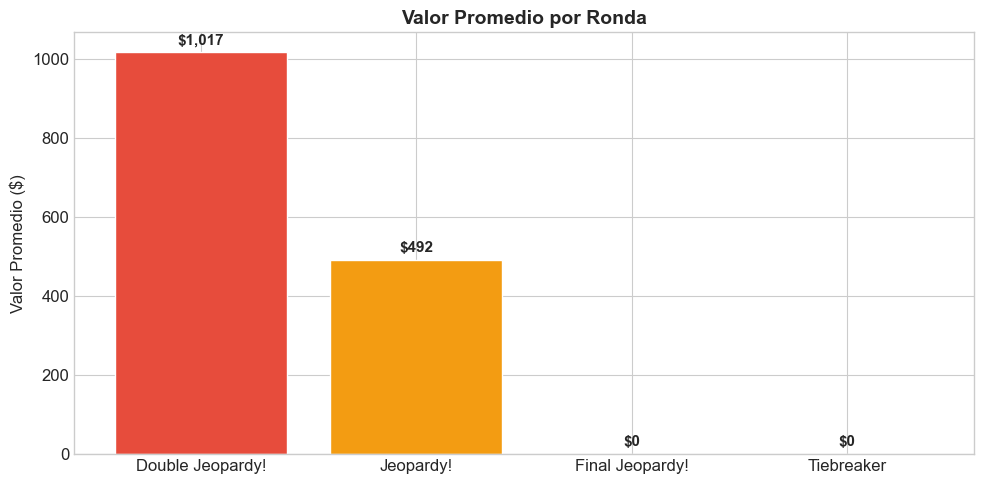

In [6]:
# Valor promedio por ronda
round_difficulty = df.groupby('Round')['Value_Numeric'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_round = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = ax.bar(round_difficulty.index, round_difficulty.values, color=colors_round[:len(round_difficulty)], edgecolor='white')
ax.set_title('Valor Promedio por Ronda', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor Promedio ($)', fontsize=12)
for bar, val in zip(bars, round_difficulty.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Analisis Temporal

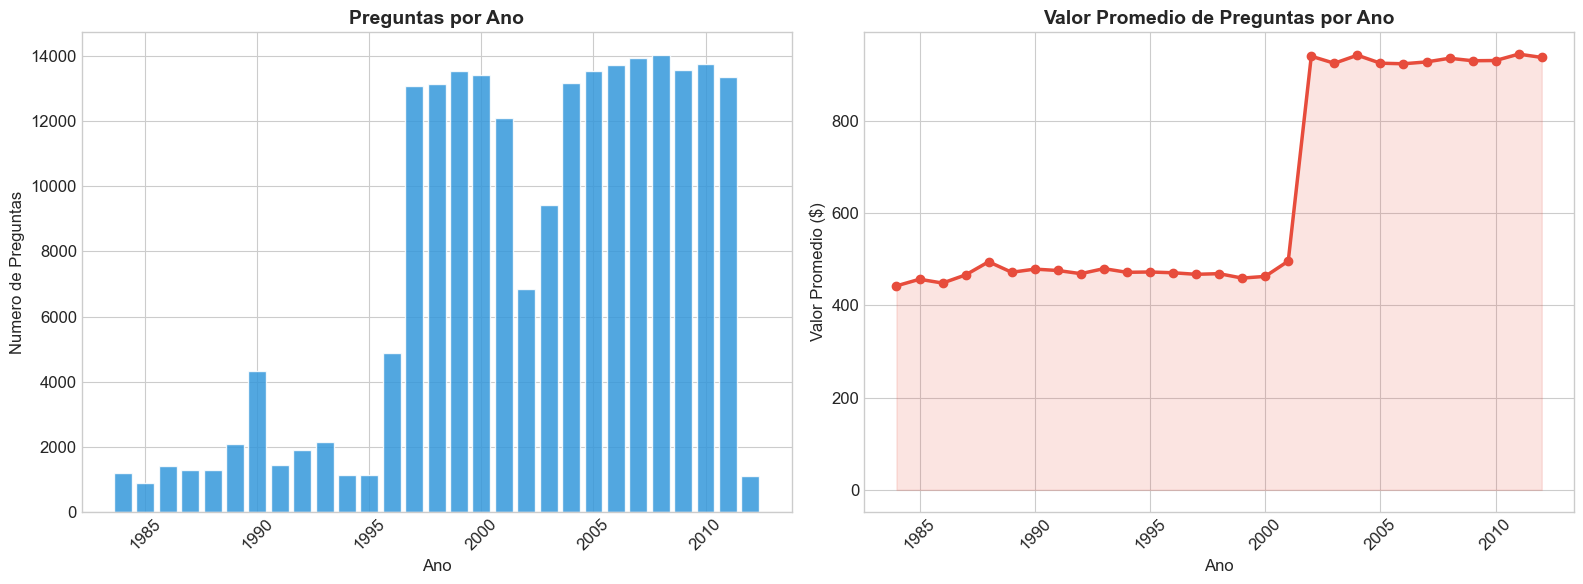

In [7]:
# Numero de preguntas por ano
yearly = df.groupby('Year').agg(
    total_questions=('Question', 'count'),
    avg_value=('Value_Numeric', 'mean'),
    unique_categories=('Category', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Preguntas por ano
axes[0].bar(yearly['Year'], yearly['total_questions'], color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Preguntas por Ano', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ano', fontsize=12)
axes[0].set_ylabel('Numero de Preguntas', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Valor promedio por ano
axes[1].plot(yearly['Year'], yearly['avg_value'], marker='o', color='#e74c3c', linewidth=2.5)
axes[1].fill_between(yearly['Year'], yearly['avg_value'], alpha=0.15, color='#e74c3c')
axes[1].set_title('Valor Promedio de Preguntas por Ano', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ano', fontsize=12)
axes[1].set_ylabel('Valor Promedio ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Analisis de Categorias

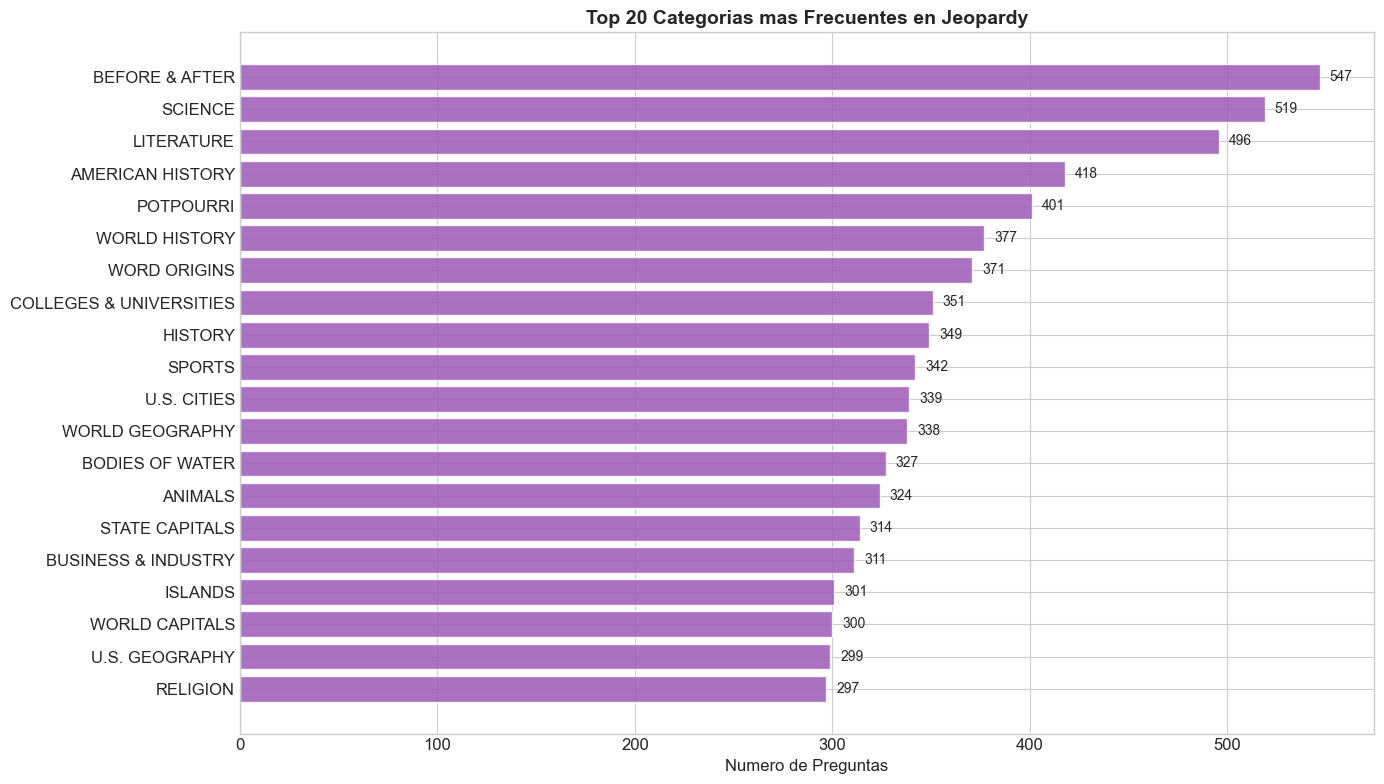

TOP 15 CATEGORIAS MAS DIFICILES (valor promedio mas alto, min 20 preguntas):
  NAME THE JAMES                      $   1,580  (n=20)
  COLLEGE COLLAGE                     $   1,460  (n=20)
  BEFORE HE WAS PRESIDENT...          $   1,425  (n=20)
  AMERICAN ART & ARTISTS              $   1,415  (n=20)
  "A" IN SCIENCE                      $   1,410  (n=20)
  BOOK TITLES                         $   1,385  (n=41)
  LITERARY CROSSWORD CLUES "S"        $   1,360  (n=30)
  ISLAND HOPPING                      $   1,327  (n=30)
  HAMLET                              $   1,325  (n=20)
  CHARACTERS IN PLAYS                 $   1,314  (n=21)
  FILL IN THE BOOK TITLE              $   1,297  (n=35)
  FROM THE GREEK                      $   1,294  (n=66)
  "C" IN SCIENCE                      $   1,264  (n=25)
  AMERICAN ISLANDS                    $   1,250  (n=20)
  4-SYLLABLE WORDS                    $   1,227  (n=30)


In [8]:
# Top 20 categorias mas frecuentes
top_categories = df['Category'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top_categories.index[::-1], top_categories.values[::-1], 
               color='#9b59b6', edgecolor='white', alpha=0.85)
ax.set_title('Top 20 Categorias mas Frecuentes en Jeopardy', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero de Preguntas', fontsize=12)

for bar, val in zip(bars, top_categories.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Categorias mas dificiles (mayor valor promedio)
cat_difficulty = df.groupby('Category').agg(
    avg_value=('Value_Numeric', 'mean'),
    count=('Question', 'count')
).reset_index()
cat_difficulty = cat_difficulty[cat_difficulty['count'] >= 20]  # solo categorias con suficientes datos
cat_difficulty = cat_difficulty.sort_values('avg_value', ascending=False).head(15)

print("TOP 15 CATEGORIAS MAS DIFICILES (valor promedio mas alto, min 20 preguntas):")
for _, row in cat_difficulty.iterrows():
    print(f"  {row['Category']:<35} ${row['avg_value']:>8,.0f}  (n={int(row['count'])})")

## 6. Analisis de Respuestas

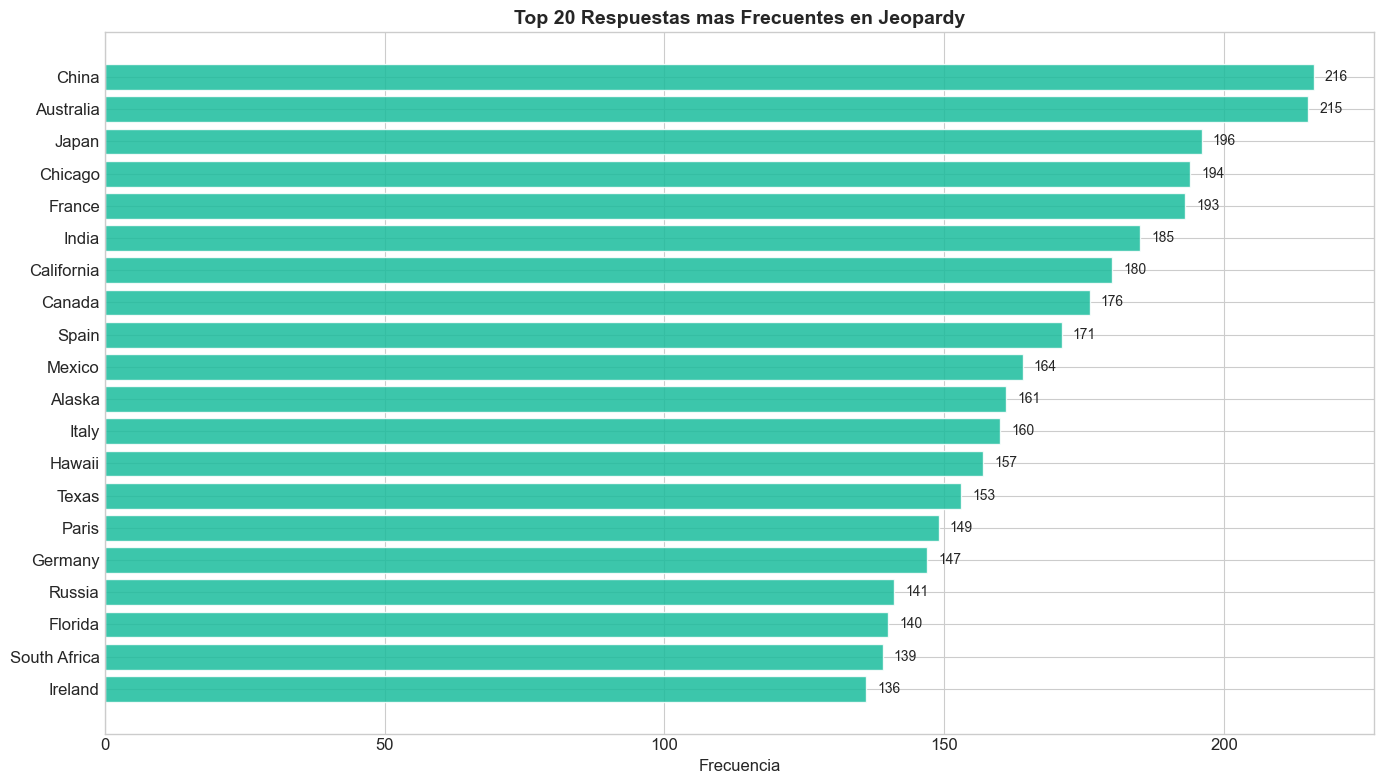

Las respuestas mas comunes tienden a ser personajes historicos,
paises y conceptos fundamentales de conocimiento general.


In [9]:
# Respuestas mas frecuentes en todo el dataset
top_answers_all = df['Answer'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top_answers_all.index[::-1], top_answers_all.values[::-1],
               color='#1abc9c', edgecolor='white', alpha=0.85)
ax.set_title('Top 20 Respuestas mas Frecuentes en Jeopardy', fontsize=14, fontweight='bold')
ax.set_xlabel('Frecuencia', fontsize=12)

for bar, val in zip(bars, top_answers_all.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Las respuestas mas comunes tienden a ser personajes historicos,")
print("paises y conceptos fundamentales de conocimiento general.")

## 7. Conclusiones

### Hallazgos principales

1. **Escala del dataset:** Con mas de 216,000 preguntas y miles de categorias, Jeopardy! cubre un espectro extremadamente amplio de conocimiento. Las categorias mas frecuentes incluyen temas generales como "Science", "History" y "Word Origins".

2. **Dificultad por ronda:** El valor de las preguntas aumenta significativamente entre rondas, con Final Jeopardy teniendo los valores mas altos. Esto confirma la estructura de dificultad progresiva del programa.

3. **Tendencias temporales:** El numero de preguntas y el valor promedio han variado a lo largo de los anos, reflejando cambios en el formato y la produccion del programa.

4. **Respuestas recurrentes:** Ciertas respuestas aparecen con alta frecuencia, lo que sugiere temas "favoritos" del programa. Esto podria ser util para estrategias de preparacion de concursantes.

5. **Funciones reutilizables:** Las funciones de filtrado desarrolladas permiten explorar el dataset de forma flexible, facilitando analisis ad-hoc sobre cualquier tema de interes.

### Aplicaciones potenciales
- **Preparacion para concursantes:** Identificar temas y respuestas mas frecuentes
- **NLP y ML:** Clasificacion automatica de preguntas, prediccion de dificultad
- **Analisis educativo:** Mapear el conocimiento valorado culturalmente en EE.UU.

---
*Exploracion de datos del programa Jeopardy!, +216,000 preguntas, analisis de patrones tematicos y temporales.*